In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import fnmatch
import matplotlib.pyplot as plt
from functools import reduce
from bs4 import BeautifulSoup
import requests
import osmnx as ox
from API_KEY import get_OneMap_token
import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from datetime import datetime
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow

import importlib

import helper_functions.utils as utils
import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.residential_attributes
import helper_functions.flood
import helper_functions.mrt_buffer
import helper_functions.drainage_work
import helper_functions.data
import helper_functions.DEM

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.flood)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.drainage_work)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)

import helper_functions.serviceArea as serviceArea
import helper_functions.amenities_dict as amenities_dict
import helper_functions.plot_utils as plot_utils
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.residential_attributes as residential_attributes
import helper_functions.flood as Flood
import helper_functions.mrt_buffer as mrt_buffer
import helper_functions.drainage_work as drainage_work
import helper_functions.data as Data
import helper_functions.DEM as DEM


# Robustness parameters

In [3]:
buffer = 200 # buffer around points/polygons so that it will intersect with residential building.
# higher buffer radius implies biffer area will intersect with residential building
depth = None # BFS depth, used for road network. TODO: If you don't want to use road network, assign as None
if depth is not None:
    road_network_buffer = True
else:
    road_network_buffer = False
adaptation_groupby_column = 'Project Name' #'Building Name' # better if fixed effect is building, 
# else use Project Name but effects may be diluted because adaption work will be a lot more extension
# months after flood list
months_after_flood_list = [1,2,3, 6, 9, 12]
# flood bins to cut flood period intervals
flood_bins = None #[-np.inf,6,12,np.inf]
# save results as save_fp filepath
save_fp = os.path.join(r"Exported_Data",
                       f"floodPrivateResidential_{datetime.today().strftime('%Y%m%d')}_buffer{buffer}_networkDepth{depth}_adaptation{adaptation_groupby_column.replace(' ','')}.csv")
print(f"Save file as: {save_fp}")

Save file as: Exported_Data\floodPrivateResidential_20260223_buffer200_networkDepthNone_adaptationProjectName.csv


# Import Data

## Import planning area and subzone

c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Index(['Name', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'], dtype='object')
Index(['Name', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'],
      dtype='object')


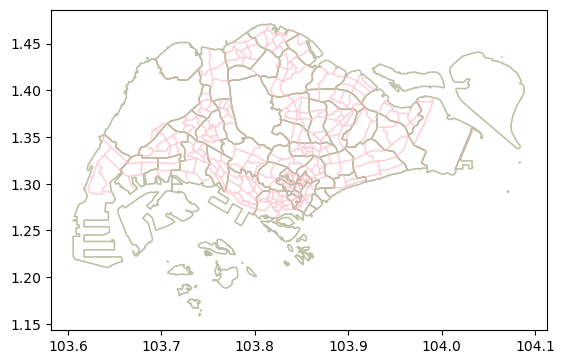

In [4]:
planningArea_shp = gpd.read_file(Data.PLANNING_AREA_FP)
subzone_shp = gpd.read_file(Data.SUBZONE_FP)
fig, ax = plt.subplots(1,1)
for shp,c in zip([planningArea_shp,subzone_shp],["green","pink"]):
    print(shp.columns)
    shp.plot(fc="none",ec=c,ax=ax,alpha=0.5)
plt.show()

## Import network

In [5]:
G_walk = ox.load_graphml(Data.G_WALK_FP)
G_car = ox.load_graphml(Data.G_CAR_FP)

## Import residential

Add spatial attributes

In [6]:
# residential_df = residential_attributes.get_private_residential_df(r"Exported_Data\Residential_transaction_2014_2024.csv")
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
# add subzone
# spatial join with subzone
residential_df = residential_df.sjoin(subzone_shp[["SUBZONE_N","geometry"]],how="left")

# # replace project names with NA with their address before unit number
# residential_df["Project Name"] = residential_df.apply(lambda x: residential_attributes.get_project_name(x),axis=1)
# add nodesID for properties
residential_df['nodesID_property'] = ox.nearest_nodes(G_car,X=residential_df['LONGITUDE'], Y=residential_df['LATITUDE'])
# # simplify Tenure and Completion Date
# residential_df['Tenure'] = residential_df['Tenure'].astype(str).apply(lambda x: residential_attributes.get_tenure(x))
# # get building age at the time of transaction sale
# residential_df['Building Age'] = residential_attributes.get_building_age(residential_df['Completion Date'], residential_df['year'])
# # simplify sale types, Consolidates New & Sub Sale
# residential_df['Type of Sale'] = residential_df['Type of Sale'].astype(str).apply(lambda x: residential_attributes.get_sale_type(x))
# # simplify Property type, Consolidates condominium etc, and consolidates landed
# residential_df['Property Type'] = residential_df['Property Type'].astype(str).apply(lambda x: residential_attributes.get_property_type(x))

print("length of residential df: ", len(residential_df))
# drop index_right
residential_df = residential_df.drop(columns=["index_right"])
print(f"Number of unique project name: {len(residential_df["Project Name"].unique())}")
print(f"Number of unique Address: {len(residential_df["Address"].unique())}")
print(f"Number of unique building name: {len(residential_df["Building Name"].unique())}")
print(f"Number of tenure types: {len(residential_df['Tenure'].unique())}")
print(f"Number of sale type types: {len(residential_df['Type of Sale'].unique())}")
print(f"Number of property types: {len(residential_df['Property Type'].unique())}")
print(f"Number of different floor number: {len(residential_df['Floor_level'].unique())}")
print(f"Number of ground floor units: {residential_df['is_ground_floor'].sum()}")
residential_df.head()

# print(residential_df['BUILDING'].unique())
# x = residential_df[residential_df['BUILDING'].apply(lambda x: "U/C" in x)][['Project Name','Address','BUILDING']]
# x['BUILDING'].sort_values().unique()

length of residential df:  267452
Number of unique project name: 8765
Number of unique Address: 230104
Number of unique building name: 26045
Number of tenure types: 2
Number of sale type types: 2
Number of property types: 2
Number of different floor number: 75
Number of ground floor units: 34327


,Building Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,LATITUDE,LONGITUDE,year,month,Building Age,Floor_level,is_ground_floor,geometry,SUBZONE_N,nodesID_property
0,481 YIO CHU KANG ROAD,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,1.386656,103.841259,2014,1,17.0,5.0,False,POINT (103.84126 1.38666),YIO CHU KANG WEST,437138895
1,52 HUME AVENUE,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,1.359094,103.765739,2014,1,12.0,1.0,True,POINT (103.76574 1.35909),HILLVIEW,7495834879
2,41 BRIGHT HILL DRIVE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New/Sub Sale,Strata,68.0,15456,...,1.357808,103.830274,2014,1,2014.0,14.0,False,POINT (103.83027 1.35781),UPPER THOMSON,4727949662
3,103 HILLVIEW RISE,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New/Sub Sale,Strata,48.0,15208,...,1.364790,103.764169,2014,1,2014.0,10.0,False,POINT (103.76417 1.36479),HILLVIEW,6540315280
4,628 UPPER THOMSON ROAD,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,1.380264,103.827764,2014,1,2.0,5.0,False,POINT (103.82776 1.38026),TAGORE,311986889


## Import flood data

- instead of merging by subzone, spatial join by buffer around floods

In [7]:
# historical flood

# (points gdf)
# flood_df = Data.get_flood_df(Data.FLOOD_FP)
# # update frroms from 2013 to 2025
# # spatial join with subzone
# flood_df = flood_df.sjoin(subzone_shp[["SUBZONE_N","PLN_AREA_N","geometry"]],how="left")
if road_network_buffer:
    # # (polygon gdf) - buffer around downstream of flooded roads
    flood_df = Data.get_flood_network_buffer(G_car, Data.FLOOD_FP, reverse = False, 
                                depth_limit = depth,
                                buffer_dist=buffer)
    # plot
    ax = planningArea_shp.plot(fc="None",ec="k")
    flood_df.plot(ax=ax,color="green",alpha=0.5)
    ref_df = Data.get_flood_buffer(G_car, Data.FLOOD_FP,radius=1)
    ref_df.plot(ax=ax,color="red",alpha=0.5)
    ax.axis('off')
    plt.show()
else:
    # # (polygon gdf) - buffer around flooded roads
    flood_df = Data.get_flood_buffer(G_car, Data.FLOOD_FP, radius=buffer)
flood_df.head()

length of flood_df:  266
length of edges:  266


,Flood_Date,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,flooded_location,geometry,year,month,u,v
0,2013-01-02,58589 (BUS STOP),NaN,GAMBAS AVE,58589 (BUS STOP),58589 (BUS STOP),NIL,25757.98510,47244.56527,1.443537,103.813172,58589 (Bus stop),"POLYGON ((103.81422 1.44111, 103.81303 1.44167...",2013,1,4736489682,4607055249
1,2013-02-08,ONE COMMONWEALTH,1,COMMONWEALTH LANE,ONE COMMONWEALTH,1 COMMONWEALTH LANE ONE COMMONWEALTH SINGAPORE...,149544,23935.14221,31862.57638,1.304428,103.796794,One Commonwealth,"POLYGON ((103.7956 1.3035, 103.79553 1.30353, ...",2013,2,1347476299,1347475127
2,2013-02-08,42059 (BUS STOP),NaN,DUNEARN RD,42059 (BUS STOP),42059 (BUS STOP),NIL,22373.58228,35402.85541,1.336445,103.782762,42059,"POLYGON ((103.78209 1.33847, 103.78228 1.33841...",2013,2,639567861,4736416191
3,2013-04-28,ANSAR GARDEN,36,CHAI CHEE AVENUE,ANSAR GARDEN,36 CHAI CHEE AVENUE ANSAR GARDEN SINGAPORE 461036,461036,38251.67532,34175.18433,1.325341,103.925435,Ansar Garden,"POLYGON ((103.92479 1.32313, 103.92429 1.32324...",2013,4,8251681826,5599434282
4,2013-09-05,34 JUBILEE ROAD SINGAPORE 128585,34,JUBILEE ROAD,NIL,34 JUBILEE ROAD SINGAPORE 128585,128585,20693.95096,32036.20270,1.305998,103.767670,34 Jubilee Rd,"POLYGON ((103.76678 1.30471, 103.76675 1.30474...",2013,9,247184659,148119053


## Import PUB-compiled flooding hotspot

In [8]:
flooding_hotspot_buffer = Data.get_flooding_hotspot_buffer(G_car, Data.FLOODING_HOTSPOT_FP, radius=buffer)
print("Earliest record of hotspot date:", flooding_hotspot_buffer["Flood_Hotspot_Date"].sort_values().values[0])
flooding_hotspot_buffer.head()

length of edges:  314
length of edges:  314
Earliest record of hotspot date: 2011-12-01T00:00:00.000000000


,Flood_Hotspot_Date,flooded_locations,responses_found,matched_location,LATITUDE,LONGITUDE,geometry,year,month
0,2017-07-01,52079 (BUS STOP),1,52079 (BUS STOP),1.329315,103.843829,"POLYGON ((103.84347 1.33118, 103.84383 1.33122...",2017,7
1,2017-07-01,MAXWELL FOOD CENTRE,1,MAXWELL FOOD CENTRE,1.280331,103.844747,"POLYGON ((103.84298 1.27907, 103.84296 1.27908...",2017,7
2,2017-07-01,MOUNT PLEASANT FLYOVER,1,MOUNT PLEASANT FLYOVER,1.327126,103.826616,"POLYGON ((103.82492 1.3256, 103.82486 1.32564,...",2017,7
3,2017-07-01,Tiong Bahru Road,1,TIONG BAHRU ROAD,1.284881,103.834043,"POLYGON ((103.83292 1.28342, 103.83291 1.28344...",2017,7
4,2011-12-01,01419 (BUS STOP),1,01419 (BUS STOP),1.302020,103.863263,"POLYGON ((103.86674 1.30236, 103.86671 1.30233...",2011,12


<Axes: >

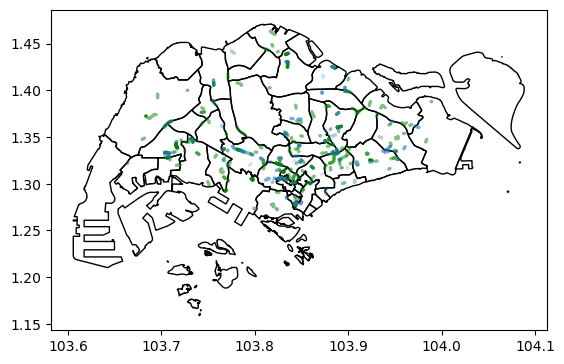

In [9]:
# plot empirical flooding and flooding hotspot
ax = planningArea_shp.plot(fc="None",ec="k")
flood_df.plot(ax=ax,alpha=0.5, color="green")
flooding_hotspot_buffer.plot(ax=ax,alpha=0.2)

## Import area near the coast prone to flooding during high-tide (3m)

In [92]:
tide_3m_polygon = Data.get_coastal_flood_prone(Data.TIDE_3M_FP)
type(tide_3m_polygon)

shapely.geometry.multipolygon.MultiPolygon

## Import flood adaptation measures

- Compare downstream road raising + buffer analysis vs just road raising + buffer

### Import road raising buffer

In [93]:
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=buffer)
road_raising_works_buffer_df.columns

Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories', 'u', 'v', 'key',
       'geometry'],
      dtype='object')

### Import downstream road raising network buffer

In [94]:
if road_network_buffer:
    road_raising_network_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                                reverse = False, 
                                                                                depth_limit = depth,
                                                                                buffer_dist=buffer)
    fig, axes = plt.subplots(1,2,figsize=(10,6))
    for ax,title in zip(axes.flatten(),["road_raising_works_buffer_df","road_raising_network_buffer_df"]):
        planningArea_shp.plot(fc="None",ec="k",alpha=0.8,ax=ax)
        road_raising_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,buffer_dist=None)
        road_raising_df.plot(ax=ax,color="red")
        ax.set_title(title)
        ax.axis('off')

    road_raising_works_buffer_df.plot(ax=axes[0],color="green",alpha=0.5)
    road_raising_network_buffer_df.plot(ax=axes[1],color="green",alpha=0.5)
    plt.show()
    road_raising_network_buffer_df.columns
else:
    road_raising_network_buffer_df = None

### Import drainage works (within 500 m buffer)

In [95]:
# includes both drainage works on roadside and outlet drains + culvert improvement works
drainage_works_df = Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, 
                                                         buffer_dist=buffer)
# drainage_works_df = Data.get_drainage_works_buffer_df(Data.DRAINAGE_WORKS_FP)
print("Type of works: ",drainage_works_df['work_categories'].unique())
drainage_works_df.columns

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drains_df['work_categories'] = "Improvement to Roadside/Outlet Drains"
c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:411: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culvert_df['work_categories'] = "

Type of works:  ['Improvement to Roadside/Outlet Drains' 'Improvement to Culvert']


Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories', 'u', 'v', 'key',
       'geometry'],
      dtype='object')

### Combine road raising + drainage works df

Unique type of adaptation works:  ['Road Raising' 'Improvement to Roadside/Outlet Drains'
 'Improvement to Culvert']


,S/N,Location,Drainage_Date,Status,year,month,work_types,location,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,u,v,key,geometry
0,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising,408735646,2641677416,0,"POLYGON ((103.84634 1.32943, 103.84654 1.32967..."
1,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising,2168300378,6754998201,0,"POLYGON ((103.83165 1.31215, 103.83161 1.31211..."
2,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising,1268263183,1268264187,0,"POLYGON ((103.94684 1.32824, 103.94673 1.32837..."
3,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,1.322983,103.952932,3.0,Road Raising,243486752,3030270542,0,"POLYGON ((103.95411 1.32159, 103.95398 1.3215,..."
4,6,Road Raising and Drainage Works at Lewis Rd,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Lewis Rd,Lewis Rd,LEWIS ROAD,...,26819.60407,33600.97291,1.320150,103.822712,1.0,Road Raising,3756077209,1744516916,0,"POLYGON ((103.82103 1.3208, 103.82106 1.32089,..."


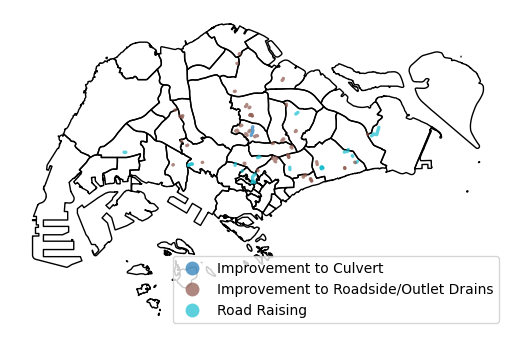

In [96]:
if road_network_buffer: # ise use road net work buffer
    road_drainage_works = pd.concat([road_raising_network_buffer_df,drainage_works_df])
else:
    road_drainage_works = pd.concat([road_raising_works_buffer_df,drainage_works_df])
# convert to a geodataframe
road_drainage_works = gpd.GeoDataFrame(data=road_drainage_works, geometry=road_drainage_works['geometry'])
# add date
road_drainage_works['Drainage_Date'] = pd.to_datetime(road_drainage_works['Drainage_Date'].apply(lambda x: '-'.join([i.zfill(2) for i in x.split('/')])),
                                                                                                    format="%d-%m-%Y")
print("Unique type of adaptation works: ", road_drainage_works["work_categories"].unique())

# plot
ax = planningArea_shp.plot(fc="None",ec="k")
road_drainage_works.plot(column="work_categories",alpha=0.7,ax=ax,
                         figsize=(15, 10),
                         legend=True,
                         legend_kwds={'loc': 'lower right'})
ax.axis('off')
# plt.savefig(r"Exported_Data\exported_figures\drainage_works_consolidated.svg", bbox_inches='tight')
road_drainage_works.head()

## Import drainage density

In [97]:
drainage_density_df = Data.get_drainage_density_df(Data.DRAINAGE_DENSITY_FP)
drainage_density_df.head()

,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,DEPOT ROAD,0.141179,0.442297,0.319195
1,2008,BUKIT MERAH,1.312479,0.411723,3.187775
2,2008,CHINATOWN,0.000000,0.587223,0.000000
3,2008,PHILLIP,0.000000,0.039438,0.000000
4,2008,RAFFLES PLACE,0.000000,0.188767,0.000000


## Import residential attributes

### Distance to top primary schools

In [98]:
travel_time_school_car = Data.get_travel_time_to_schools(Data.PRI_SCH_CAR_TRAVEL_FP,suffix="car")
travel_time_school_walk = Data.get_travel_time_to_schools(Data.PRI_SCH_WALK_TRAVEL_FP,suffix="walk")
# only select within 1/2km and min distance
travel_time_school_car = travel_time_school_car[["Address","Sale_Date"]+travel_time_school_car.columns[-3:].to_list()]
travel_time_school_walk = travel_time_school_walk[["Address","Sale_Date"]+travel_time_school_walk.columns[-3:].to_list()]
travel_time_school_walk.head()

,Address,Sale_Date,sch_within_1km_walk,sch_within_2km_walk,sch_min_distance_walk
0,481 YIO CHU KANG ROAD #05-02,2014-01-02,True,True,736.056163
1,52 HUME AVENUE #01-16,2014-01-02,False,False,2226.148647
2,41 BRIGHT HILL DRIVE #14-01,2014-01-02,False,False,NaN
3,103 HILLVIEW RISE #10-11,2014-01-03,False,True,1386.446251
4,628 UPPER THOMSON ROAD #05-61,2014-01-03,False,True,1863.025218


### Workplace cluster

In [99]:
workplace_cluster_df = Data.get_workplace_cluster(G_car,Data.WORKPLACE_CLUSTER_FP)
workplace_cluster_df.head()

,PLN_AREA_N,LU_DESC,PLN_AREA_C,REGION_N,REGION_C,LATITUDE,LONGITUDE,node_ID,geometry
2,BISHAN,COMMERCIAL,BS,CENTRAL REGION,CR,1.353185,103.838386,310582393,POINT (103.83839 1.35319)
5,BUKIT MERAH,COMMERCIAL,BM,CENTRAL REGION,CR,1.282412,103.823409,409638755,POINT (103.82341 1.28241)
7,BUKIT TIMAH,RESIDENTIAL WITH COMMERCIAL AT 1ST STOREY,BT,CENTRAL REGION,CR,1.333500,103.786494,6144151504,POINT (103.78649 1.3335)
12,DOWNTOWN CORE,UTILITY,DT,CENTRAL REGION,CR,1.286690,103.852118,7202314880,POINT (103.85212 1.28669)
13,GEYLANG,UTILITY,GL,CENTRAL REGION,CR,1.316940,103.885235,8655329609,POINT (103.88524 1.31694)


In [100]:
travel_time_work_cluster = residential_attributes.get_travel_time_to_destination(G_car,residential_df,residential_nodes_column_name='nodesID_property',
                                                      destination_df=workplace_cluster_df[workplace_cluster_df['PLN_AREA_N'].isin(['DOWNTOWN CORE','TAMPINES','JURONG EAST','ANG MO KIO', 'WOODLANDS'])],
                                                      destination_nodes_column_name="node_ID")
travel_time_work_cluster

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\residential_attributes.py:188: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  travel_time_df['min_travel_time_work_region'] = travel_time_df.iloc[:,3:].idxmin(axis=1).str.replace("_travel_time","")


,nodesID_property,Address,Sale_Date,DOWNTOWN CORE_travel_time,TAMPINES_travel_time,WOODLANDS_travel_time,ANG MO KIO_travel_time,JURONG EAST_travel_time,min_travel_time_work_region,min_travel_time_work
0,437138895,481 YIO CHU KANG ROAD #05-02,2014-01-02,817.593729,969.927205,582.116356,55.611099,1180.705147,ANG MO KIO,55.611099
1,7495834879,52 HUME AVENUE #01-16,2014-01-02,906.462413,1192.301903,679.252533,894.971270,495.595984,JURONG EAST,495.595984
2,4727949662,41 BRIGHT HILL DRIVE #14-01,2014-01-02,691.396043,899.017365,712.713872,231.689071,947.142241,ANG MO KIO,231.689071
3,6540315280,103 HILLVIEW RISE #10-11,2014-01-03,966.753995,1210.953524,656.295142,899.633176,525.733762,JURONG EAST,525.733762
4,311986889,628 UPPER THOMSON ROAD #05-61,2014-01-03,844.905078,1021.738837,610.659748,81.448453,1154.819436,ANG MO KIO,81.448453
...,...,...,...,...,...,...,...,...,...,...
267447,1867272247,66 POTONG PASIR AVENUE 1 #13-30,2025-06-18,522.079357,627.002973,1033.783249,544.543182,1061.844320,DOWNTOWN CORE,522.079357
267448,244495367,19 WOODLANDS AVENUE 6 #05-26,2025-06-18,1132.816728,1135.971369,175.528054,439.165934,1101.746324,WOODLANDS,175.528054
267449,239824768,46 MOUNT VERNON ROAD #01-47,2025-06-19,635.590392,533.275843,1034.190587,530.862090,1136.763382,ANG MO KIO,530.862090
267450,4709369116,21 BIDADARI PARK DRIVE #10-26,2025-06-20,503.501868,608.425483,955.201743,465.961677,1043.266830,ANG MO KIO,465.961677


### Malls

In [101]:
malls_df = Data.get_mall_df(Data.MALLS_FP)
malls_df.head()

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,Mall Name,nodesID_car_mall,nodesID_walk_mall,geometry
0,ALEXANDRA RETAIL CENTRE (ARC),460,ALEXANDRA ROAD,ALEXANDRA RETAIL CENTRE (ARC),460 ALEXANDRA ROAD ALEXANDRA RETAIL CENTRE (AR...,119963,24447.647553565,28514.458416285,1.274149,103.801399,Alexandra Retail Centre,435833857,5269394155,POINT (103.8014 1.27415)
1,AMK HUB,53,ANG MO KIO AVENUE 3,AMK HUB,53 ANG MO KIO AVENUE 3 AMK HUB SINGAPORE 569933,569933,29687.0565410079,39045.6241728477,1.369389,103.848478,AMK Hub,435824984,4540628535,POINT (103.84848 1.36939)
2,BEDOK MALL,311,NEW UPPER CHANGI ROAD,BEDOK MALL,311 NEW UPPER CHANGI ROAD BEDOK MALL SINGAPORE...,467360,38676.9034392368,34108.3360637221,1.324736,103.929256,Bedok Mall,4675722406,8982593125,POINT (103.92926 1.32474)
3,BUGIS JUNCTION,200,VICTORIA STREET,BUGIS JUNCTION,200 VICTORIA STREET BUGIS JUNCTION SINGAPORE 1...,188021,30458.7085178969,31274.8305191435,1.299113,103.855411,Bugis Junction,232119579,4755817437,POINT (103.85541 1.29911)
4,BUGIS CUBE,470,NORTH BRIDGE ROAD,BUGIS CUBE,470 NORTH BRIDGE ROAD BUGIS CUBE SINGAPORE 188735,188735,30483.6570850834,31167.3475166354,1.298141,103.855635,Bugis+,232119579,11037228265,POINT (103.85564 1.29814)


### Parks

In [102]:
parks_df = Data.get_park_df(Data.PARKS_FP)
parks_df.head()

,FID,N_RESERVE,L_CODE,NAME,Shape_Leng,Shape_Area,geometry
0,0,1,NRNP01,LABRADOR NATURE RESERVE,1817.143003,1.005354e+05,"POLYGON ((103.80273 1.26782, 103.80276 1.26783..."
1,1,1,NRNP03,BUKIT TIMAH NATURE RESERVE,7747.590684,1.623659e+06,"POLYGON ((103.77687 1.36072, 103.77693 1.36103..."
2,2,1,NRNP05,UPPER SELETAR RESERVOIR PARK,3625.555022,1.344146e+05,"POLYGON ((103.80826 1.40542, 103.80811 1.4055,..."
3,3,1,NRNP06,UPPER PEIRCE RESERVOIR PARK,1523.955588,6.916462e+04,"POLYGON ((103.81347 1.37173, 103.81331 1.37201..."
4,4,0,NRNP08,THOMSON NATURE PARK,4263.882120,5.117329e+05,"POLYGON ((103.82141 1.38599, 103.82134 1.38603..."


### MRT (within 400m buffer)

In [103]:
mrt_buffer_df = Data.get_MRT_buffer_df(Data.MRT_FP, buffer_dist=buffer)
mrt_buffer_df.head()

,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line,stn_code,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,geometry
0,NS10,ADMIRALTY MRT STATION,1996-02-10,1996.0,2.0,1.0,NS,NS10,ADMIRALTY MRT STATION (NS10),70,WOODLANDS AVENUE 7,ADMIRALTY MRT STATION (NS10),70 WOODLANDS AVENUE 7 ADMIRALTY MRT STATION (N...,738344,24402.386627,46918.506802,1.440589,103.800991,"POLYGON ((103.80279 1.44059, 103.80278 1.44041..."
1,EW9,ALJUNIED MRT STATION,1989-11-04,1989.0,11.0,1.0,EW,EW9,ALJUNIED MRT STATION (EW9),81,LORONG 25 GEYLANG,ALJUNIED MRT STATION (EW9),81 LORONG 25 GEYLANG ALJUNIED MRT STATION (EW9...,388310,33518.604869,33190.002017,1.316433,103.882906,"POLYGON ((103.8847 1.31643, 103.88469 1.31626,..."
3,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987.0,11.0,1.0,NS,NS16,ANG MO KIO MRT STATION (NS16),2795,ANG MO KIO AVENUE 8,ANG MO KIO MRT STATION (NS16),2795 ANG MO KIO AVENUE 8 ANG MO KIO MRT STATIO...,569812,29807.261147,39105.735995,1.369933,103.849558,"POLYGON ((103.85135 1.36993, 103.85135 1.36976..."
4,SE3,BAKAU LRT STATION,2003-01-18,2003.0,1.0,1.0,SE,SE3,BAKAU LRT STATION (SE3),50,RIVERVALE DRIVE,BAKAU LRT STATION (SE3),50 RIVERVALE DRIVE BAKAU LRT STATION (SE3) SIN...,545053,36023.433345,41102.996687,1.387994,103.905415,"POLYGON ((103.90721 1.38799, 103.9072 1.38782,..."
5,BP9,BANGKIT LRT STATION,1999-11-06,1999.0,11.0,1.0,BP,BP9,BANGKIT LRT STATION (BP9),20,BUKIT PANJANG RING ROAD,BANGKIT LRT STATION (BP9),20 BUKIT PANJANG RING ROAD BANGKIT LRT STATION...,679939,21248.056588,40221.448411,1.380022,103.772647,"POLYGON ((103.77444 1.38002, 103.77444 1.37984..."


# Merge all datasets

## Initialise master df

In [135]:
master_df = copy.deepcopy(residential_df)
# # get floor number for high rises only
# master_df['Floor_level'] = master_df.apply(lambda x: residential_attributes.get_floor_number(x),axis=1)
# # for NA values in flood level, replace NA with 0 because they are usually landed properties
# master_df['Floor_level'] = master_df['Floor_level'].fillna(value=0)
# # create binary variable for ground floor
# master_df['is_ground_floor'] = master_df.apply(lambda x: residential_attributes.get_ground_floor(x), axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property'],
      dtype='object')
length of df:  267452


## Merge with travel time to top 5 workplace cluster

In [105]:
master_df = master_df.merge(travel_time_work_cluster)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work'],
      dtype='object')
length of df:  267452


## Merge with travel time to top primary schools

In [106]:
master_df = reduce(lambda  left,right: pd.merge(left,right,how="left",on=["Address","Sale_Date"]),[master_df,travel_time_school_car,travel_time_school_walk])
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

## Merge with centrality metrics

In [107]:
master_df = residential_attributes.add_centrality_metrics(master_df,residential_nodes_column_name='nodesID_property',
                                                          standardise=True)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

## Merge with malls

In [108]:
# create buffer aorund malls (points)
mall_buffer_df = residential_attributes.get_malls(G_walk,malls_df,radius=buffer,plot=False)
master_df = residential_attributes.add_malls(master_df,mall_buffer_df,groupby_columns = ['Project Name','Address','Sale_Date'])
print(master_df.columns)
print("length of df: ", len(master_df))

6373456776: Number of nodes less than 2: 1
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 's

## Merge with parks

In [109]:
master_df = residential_attributes.add_parks(master_df, parks_df, radius=buffer, plot=False)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

## Merge with MRT

In [110]:
master_df = mrt_buffer.add_mrt_buffer(master_df,mrt_buffer_df,
                              address_column = "Address", sale_date_column = "Sale_Date",
                                construction_period = 6)
print(master_df.columns)
print("length of df: ", len(master_df))

length of df after spatial joining residential and train df:  270953
length of train df:  267452
length of df after merging residential and train df:  267452
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_trav

## Merge with DEM

In [111]:
master_df["DEM"] = master_df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

## Merge with flood event

- Use 6/12/18 months to flag transaction records that has floods occurring within 6/12/18 months
- Include continuous weeks-since-flood as robustness checks (*Note: this is added after checking whether location is in a flood prone area as a check to see if the area has experienced repeated flooding. Reduce noise in dataset by only examining areas with repeated flooding)

*Notes*:
- if use groupby variable as Address, then the months after flood events would not change much because Address specifies a particular unit which would be too granular

In [136]:
# merging of master df with flood df by location intersection ONLY
master_df = Flood.add_historical_flooding(master_df, 
                                       flood_df[["flooded_location","Flood_Date","geometry"]],
                                       sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
print("Number of flooded entries: ",len(master_df[~master_df['flooded_location'].isna()]))
print("Length of df: ",len(master_df))

# add boolean flags on whether obs has recent flood occurrences
for months_after_flood in months_after_flood_list:
    master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",
                                              months_after_flood=months_after_flood,
                                            groupby_column=adaptation_groupby_column,
                                            drop_duplicate_column = ["Project Name","Address","Sale_Date"])
    
    print(f"Number of flood within months: {master_df[f'within_{months_after_flood}_months_post_flood'].sum()}")

# [6 MOUNT VERNON ROAD #01-47], 40 PINE GROVE #24-10
# master_df[master_df['within_6_months_post_flood']==True][["Project Name","Address","Sale_Date","flooded_location","Flood_Date"]]
#.isin(["32 PINE GROVE #22-09","40 PINE GROVE #24-10"])]#

# master_df = master_df.merge(flood_df[["flooded_location","Flood_Date","SUBZONE_N"]],how="left",
#                     left_on=["SUBZONE_N",'Sale_Date'], 
#                     right_on=["SUBZONE_N",'Flood_Date'],suffixes=('_property','_flood'))
# master_df = master_df.drop_duplicates(subset=['Project Name','Address','Sale_Date'])
# master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=6,
#                                           groupby_column=["SUBZONE_N"])
# master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=12,
#                                           groupby_column=["SUBZONE_N"])
# master_df = Flood.add_flood_within_months(master_df,sale_date_column="Sale_Date",months_after_flood=18,
#                                           groupby_column=["SUBZONE_N"])
# master_df = Flood.add_weeks_since_flood(master_df,sale_date_column="Sale_Date", 
#                                         groupby_column=["SUBZONE_N"],fillna=np.nan)
# add continuous variable on weeks/months after flood
master_df = Flood.add_time_since_flood(master_df,sale_date_column="Sale_Date",
                                       groupby_column=adaptation_groupby_column,
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"], 
                                       fillna=np.nan,
                                       units="months", bins=flood_bins)
print(f"Number of transactions with flood: {len(master_df[~master_df['Flood_Date'].isna()])}")
print(master_df.columns)
print("length of df: ", len(master_df))

Number of flooded entries:  22289
Length of df:  267452
Number of flood within months: 431
Number of flood within months: 825
Number of flood within months: 1443
Number of flood within months: 2843
Number of flood within months: 3999
Number of flood within months: 4929
Number of transactions with flood: 22289
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'flooded_location', 'Flood_Date', 'with

### Stacked DID
- Define treatment clearly (i.e. properties affected by flood determined by buffer radius)
    - treated properties: properties within buffer radius of flood area (labelled as True)
    - control group: properties outside buffer radius of flood area (labelled as False)
- Define post-treatment clearly
    - post-treatment: post $t$ duration of flood (i.e. within $t$ months of flood)

In [ ]:
# add column to label treated properties i.e. within flood_buffer
flood_union = flood_df['geometry'].union_all()
master_df[f'flood_buffer{buffer}'] = master_df['geometry'].apply(lambda x: flood_union.intersects(x))
print(f"Number of properties within {buffer} m buffer: {master_df['flood_buffer'].sum()}")
print(master_df.columns)
print("length of df: ", len(master_df))

Number of properties within 200 m buffer: 32193
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'flooded_location', 'Flood_Date', 'within_1_months_post_flood',
       'within_2_months_post_flood', 'within_3_months_post_flood',
       'within_6_months_post_flood', 'within_9_months_post_flood',
       'within_12_months_post_flood', 'time_since_flood', 'flood_buffer200'],
      dtype='object')
leng

## Merge with PUB-compiled flooding hotspot
- Identifies if an area is within a flood prone area for that transaction year
    - if publication date of the flooding hotspot is after the transaction date, it means the location is in a flood prone area
- Obtain the latest flooding hotspot date
- Directly examine whether flood occurs in a flood-prone area or not, and if flood recency has an impact on property price for area that is flood-prone and for area that is not flood-prone

In [113]:
# master_df = Flood.add_within_flooding_hotspot_buffer(master_df,flooding_hotspot_buffer,
#                                                     #  groupby_column = ["Project Name"], 
#                                                     groupby_column=[adaptation_groupby_column],
#                                                      sale_date_column="Sale_Date")

master_df = Flood.add_within_flooding_hotspot_buffer(master_df, 
                                        flooding_hotspot_buffer[['Flood_Hotspot_Date', 'flooded_locations','geometry']],
                                       groupby_column = [adaptation_groupby_column], sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
print(f"Number of obs within flooding hotspot: {master_df['within_flooding_hotspot'].sum()}")
# x = x[["Project Name","Address","Sale_Date",'Flood_Hotspot_Date', "latest_flooding_hotspot_date",'within_flooding_hotspot','flooded_locations']]
# x[~x['Flood_Hotspot_Date'].isna()]
# x[(x['within_flooding_hotspot']==True)].sort_values(by=['Flood_Hotspot_Date','Project Name']).tail(20)
print(master_df.columns)
print("length of df: ", len(master_df))

Number of obs within flooding hotspot: 9851
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', '

## Merge with coastal flood prone area

In [114]:
master_df["prone_to_high_tide"] = master_df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

## Merge with drainage work type

In [115]:
# print(sorted(drainage_works_df.columns))
# print(sorted(road_drainage_works.columns))

# # spatial join drainage works with master_df - this will produce duplicated rows because different drianage work categories can intersect with the same residential location at the same time
# #  (i.e. multiple works carried out simultaneously at the same location)
# master_drainage_df = master_df.sjoin(road_drainage_works[["work_categories","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# print("length of df before merging: ", len(master_drainage_df))
# print(master_drainage_df['work_categories'].value_counts())
# # aggregate drainage works by the same location e.g. work A and B are carried out at the same location but exists as separate rows in the df, 
# # aggregate them such that it shows A & B works in one row instead of 2 row
# x = master_df.merge(master_drainage_df.groupby(['Project Name','Address','Sale_Date']).agg({'work_categories': lambda x: ','.join([str(i) for i in set(x.tolist())])}).reset_index(level=[0]),
#         on=['Project Name','Address','Sale_Date'])
# print("length of df after merging: ", len(x))
# print(x['work_categories'].value_counts())
# #=========================================================

# x = master_df.sjoin(road_drainage_works[["work_categories","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# print("Number of unique work categories: ",x['work_categories'].unique())
# print(x['work_categories'].value_counts())
# # remove duplicated index
# x = x[~x.index.duplicated(keep="first")]
# print(x['work_categories'].value_counts())
# print("Number of unique work categories: ",x['work_categories'].unique())
# x = x.drop(columns=['index_drainage'])
# print(x['work_categories'].value_counts())
# print("Number of unique work categories: ",x['work_categories'].unique())
# x = drainage_work.add_drainage_period(x, construction_period=0,
#                                               groupby_column=["Project Name"])
# # replace construction with before
# x['drainage_period'] = x['drainage_period'].apply(lambda x: "before" if x=="construction" else x)
# print(x.columns)
# print("length of df: ", len(x))



# x = add_road_drainage_works(master_df, road_drainage_works[["work_categories","ROAD_NAME","geometry","Drainage_Date"]],
#                             sale_date_column="Sale_Date",
#                             drop_duplicate_column = ["Project Name","Address","Sale_Date"])
# # x

# # x[x['work_categories']=='Improvement to Roadside/Outlet Drains,Improvement to Culvert'].sort_values(by='Project Name')
# print(x['work_categories'].value_counts())
# print(x['drainage_period'].value_counts())

# x[["Project Name","Sale_Date","Drainage_Date","drainage_period","work_categories"]]#.sort_values(by='Project Name')

In [116]:
# master_df = master_df.sjoin(road_drainage_works[["work_categories","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# print("length of df: ", len(master_df))
# print(master_df['work_categories'].value_counts())
# # remove duplicated index - this method corresponds with merging the aggregated data ie. HDB resale method
# master_df = master_df[~master_df.index.duplicated(keep="first")]
# master_df = master_df.drop(columns=['index_drainage'])
# print("length of df: ", len(master_df))
# print(master_df['work_categories'].value_counts())

# master_df = master_df.sjoin(drainage_works_df[["work_categ","year","month","ROAD_NAME","geometry"]],how="left",
#                                                         rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
# # remove duplicated index
# master_df = master_df[~master_df.index.duplicated(keep="first")]
# master_df = master_df.drop(columns=['index_drainage'])
# master_df = drainage_work.add_drainage_period(master_df, construction_period=6)
# print(master_df.columns)
# print("length of df: ", len(master_df))

## Merge with drainage period

Identify if drainage work took place before and after Sale Date

In [117]:
# master_df = drainage_work.add_drainage_period(master_df, construction_period=0,
#                                               groupby_column=[adaptation_groupby_column])
# # replace construction with before
# master_df['drainage_period'] = master_df['drainage_period'].apply(lambda x: "before" if x=="construction" else x)
master_df = drainage_work.add_road_drainage_works(master_df, 
                            road_drainage_works[["work_categories","ROAD_NAME","geometry","Drainage_Date"]],
                            sale_date_column="Sale_Date",
                            groupby_column = [adaptation_groupby_column],
                            drop_duplicate_column = ["Project Name","Address","Sale_Date"])
print(master_df['work_categories'].value_counts())
print(master_df['drainage_period'].value_counts())
print(master_df.columns)
print("length of df: ", len(master_df))
print("Number of unique work categories: ", master_df['work_categories'].unique())
print(master_df['work_categories'].value_counts())

work_categories
none                                                  251919
Improvement to Roadside/Outlet Drains                  10642
Road Raising                                            3168
Improvement to Culvert                                  1689
Road Raising,Improvement to Roadside/Outlet Drains        34
Name: count, dtype: int64
drainage_period
never     244330
after      17822
before      5300
Name: count, dtype: int64
Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Fl

## Merge with drainage density

In [118]:
master_df = master_df.merge(drainage_density_df,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"])
master_df = drainage_work.add_drainage_density(master_df,drainage_density_df,sale_date_column = "Sale_Date",noData=0,
                                               groupby_column=["SUBZONE_N"])
print(master_df.columns)
print("length of df: ", len(master_df))

Index(['Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'year', 'month', 'Building Age', 'Floor_level',
       'is_ground_floor', 'geometry', 'SUBZONE_N', 'nodesID_property',
       'DOWNTOWN CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG MO KIO_travel_time',
       'JURONG EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distan

# Simplify data

In [119]:
# only keep relevant columns in master_df

columns_unkeep = ['Area (SQFT)','Unit Price ($ PSF)', 'Nett Price($)',
                  'Number of Units','Purchaser Address Indicator','SEARCHVAL', 'BLK_NO',
       'ADDRESS', 'POSTAL', 'X', 'Y',
       'LATITUDE', 'LONGITUDE', 'geometry','nodesID_property','year_drainage_density',
       'drainage_length_km', 'area_km2','flooded_location','Flood_Date',"latest_flooding_hotspot_date"]
master_df_minimal =  master_df.drop(columns = columns_unkeep)
# rename columns for readability in R
rename_columns = {c: re.sub(r"\s|/","_",c) for c in master_df_minimal.columns}
master_df_minimal = master_df_minimal.rename(columns = rename_columns)
print(master_df_minimal.columns)
print("length of df: ", len(master_df_minimal))
master_df_minimal.head()

Index(['Building_Name', 'Transacted_Price_($)', 'Sale_Date', 'Address',
       'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)', 'Unit_Price_($_PSM)',
       'Property_Type', 'Tenure', 'Completion_Date', 'Postal_Code',
       'Postal_District', 'Postal_Sector', 'REGION_N', 'PLN_AREA_N',
       'ROAD_NAME', 'Project_Name', 'year', 'month', 'Building_Age',
       'Floor_level', 'is_ground_floor', 'SUBZONE_N',
       'DOWNTOWN_CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG_MO_KIO_travel_time',
       'JURONG_EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_walk', 'betweeness_centrality',
       'closeness_centrality', 'malls_within_400m', 'parks_within_400m',
       'existing_stn_count', 'upcoming_stn_count', 'stn_lines', 'DEM',
       'within_1_months_post_flood', 'within_2_months_pos

,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,Tenure,...,within_3_months_post_flood,time_since_flood,Flood_Hotspot_Date,flooded_locations,within_flooding_hotspot,prone_to_high_tide,work_categories,Drainage_Date,drainage_period,drainage_density_(km_km2)
0,481 YIO CHU KANG ROAD,950000,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,Condominium/Apartment,Leasehold,...,False,NaN,NaT,NaN,False,False,none,NaT,never,3.771018
1,52 HUME AVENUE,1650000,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,Condominium/Apartment,Freehold,...,False,NaN,NaT,NaN,False,False,none,NaT,never,3.771018
2,41 BRIGHT HILL DRIVE,1051000,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New/Sub Sale,Strata,68.0,15456,Condominium/Apartment,Leasehold,...,False,NaN,NaT,NaN,False,False,none,NaT,never,3.771018
3,103 HILLVIEW RISE,730000,2014-01-03,103 HILLVIEW RISE #10-11,New/Sub Sale,Strata,48.0,15208,Condominium/Apartment,Leasehold,...,False,NaN,NaT,NaN,False,False,none,NaT,never,3.771018
4,628 UPPER THOMSON ROAD,2518000,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,Condominium/Apartment,Freehold,...,False,NaN,NaT,NaN,False,False,none,NaT,never,3.771018


# Export data

In [120]:
master_df_minimal.to_csv(save_fp,index=False)

# Summary statistics

In [121]:
master_df_minimal.columns

Index(['Building_Name', 'Transacted_Price_($)', 'Sale_Date', 'Address',
       'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)', 'Unit_Price_($_PSM)',
       'Property_Type', 'Tenure', 'Completion_Date', 'Postal_Code',
       'Postal_District', 'Postal_Sector', 'REGION_N', 'PLN_AREA_N',
       'ROAD_NAME', 'Project_Name', 'year', 'month', 'Building_Age',
       'Floor_level', 'is_ground_floor', 'SUBZONE_N',
       'DOWNTOWN_CORE_travel_time', 'TAMPINES_travel_time',
       'WOODLANDS_travel_time', 'ANG_MO_KIO_travel_time',
       'JURONG_EAST_travel_time', 'min_travel_time_work_region',
       'min_travel_time_work', 'sch_within_1km_car', 'sch_within_2km_car',
       'sch_min_distance_car', 'sch_within_1km_walk', 'sch_within_2km_walk',
       'sch_min_distance_walk', 'betweeness_centrality',
       'closeness_centrality', 'malls_within_400m', 'parks_within_400m',
       'existing_stn_count', 'upcoming_stn_count', 'stn_lines', 'DEM',
       'within_1_months_post_flood', 'within_2_months_pos

In [122]:
master_df_minimal1 = master_df_minimal[['Property_Type', 'Floor_level','Tenure',
    'is_ground_floor','malls_within_400m','parks_within_400m',
    'within_flooding_hotspot','prone_to_high_tide', 'work_categories','drainage_period']+
    [f"within_{i}_months_post_flood" for i in months_after_flood_list]]
object_columns = master_df_minimal1.apply(lambda x: x.dtype not in ['int64','float64'])
# object_columns[object_columns].index
# master_df_minimal1[object_columns[object_columns].index.to_list()].groupby(['Property_Type']).apply(lambda x: x.value_counts()).to_frame()
value_counts = []
for col_name, col_data in master_df_minimal1[object_columns[object_columns].index.to_list()].items():
    vc = col_data.value_counts().to_frame()
    value_counts.append(vc)
    # print(vc.index, vc.columns, vc.index.name)

save_dir = os.path.join(os.getcwd(),"Exported_Data")
pd.concat(value_counts, keys = [i.index.name for i in value_counts]).reset_index(
    names=['Variable','Categories']).to_csv(os.path.join(save_dir,f"PrivRes_summaryStatistics_{datetime.today().strftime('%Y%m%d')}.csv"),index=False)

# Plot figures

## Plot distribution of private and HDB residential

In [123]:
# import HDB
HDB_residential_df = Data.get_hdb_residential_df(Data.HDB_RESALE_RESIDENTIAL_FP)
print(f"Length of HDB_residential_df: {len(HDB_residential_df)}")
# drop duplicates where all content across columns are the same!
HDB_residential_df = HDB_residential_df.drop_duplicates(keep="first")
print(f"Length of HDB_residential_df after dropping duplicates: {len(HDB_residential_df)}")
# create a unique index that would identify each unique transaction so there is no need to keep quoting 5 column names to identify unique columns
HDB_residential_df['unique_index'] = HDB_residential_df[['Address','month_year','Transacted Price ($)','Area (SQM)','remaining_lease']].astype(str).apply(lambda x: ''.join(x), axis=1)
# add subzone
# spatial join with subzone, planning area and region
HDB_residential_df = HDB_residential_df.sjoin(subzone_shp[["SUBZONE_N","PLN_AREA_N",'REGION_N',"geometry"]],how="left")
HDB_residential_df.head()

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:101: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  resale_prices_df = pd.read_csv(fp)


Length of HDB_residential_df: 265007
Length of HDB_residential_df after dropping duplicates: 264453


,month_year,town,Property Type,block,Project Name,Floor_level,Area (SQM),flat_model,lease_commence_date,Transacted Price ($),...,Building Age,Address,Sale_Date,is_ground_floor,geometry,unique_index,index_right,SUBZONE_N,PLN_AREA_N,REGION_N
656847,2015-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,middle,60.0,premium/DBSS/Type S1/2,1986,255000.0,...,29.0,174 ANG MO KIO AVE 4 07 TO 09,2015-01-01,False,POINT (103.83946 1.37648),174 ANG MO KIO AVE 4 07 TO 092015-01255000.060...,110,KEBUN BAHRU,ANG MO KIO,NORTH-EAST REGION
656848,2015-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,low,68.0,generation/Model A,1981,275000.0,...,34.0,541 ANG MO KIO AVE 10 01 TO 03,2015-01-01,False,POINT (103.85659 1.36677),541 ANG MO KIO AVE 10 01 TO 032015-01275000.06...,162,CHONG BOON,ANG MO KIO,NORTH-EAST REGION
656849,2015-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,low,69.0,generation/Model A,1980,285000.0,...,35.0,163 ANG MO KIO AVE 4 01 TO 03,2015-01-01,False,POINT (103.83946 1.37648),163 ANG MO KIO AVE 4 01 TO 032015-01285000.069...,110,KEBUN BAHRU,ANG MO KIO,NORTH-EAST REGION
656850,2015-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,low,68.0,generation/Model A,1979,290000.0,...,36.0,446 ANG MO KIO AVE 10 01 TO 03,2015-01-01,False,POINT (103.85659 1.36677),446 ANG MO KIO AVE 10 01 TO 032015-01290000.06...,162,CHONG BOON,ANG MO KIO,NORTH-EAST REGION
656851,2015-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,middle,68.0,generation/Model A,1980,290000.0,...,35.0,557 ANG MO KIO AVE 10 07 TO 09,2015-01-01,False,POINT (103.85659 1.36677),557 ANG MO KIO AVE 10 07 TO 092015-01290000.06...,162,CHONG BOON,ANG MO KIO,NORTH-EAST REGION


In [124]:
HDB_residential_df_copy = copy.deepcopy(HDB_residential_df)
HDB_residential_df_copy['Property Type'] = 'HDB'
combined_residential_df = pd.concat([residential_df[['Property Type','geometry']],
                                     HDB_residential_df_copy[['Property Type','geometry']]
                                     ])

print(combined_residential_df['Property Type'].unique())
combined_residential_df.head()
print(type(combined_residential_df))



['Condominium/Apartment' 'Landed' 'HDB']
<class 'geopandas.geodataframe.GeoDataFrame'>


(np.float64(103.58156158713254),
 np.float64(104.11262218316446),
 np.float64(1.143094894059516),
 np.float64(1.486378638658784))

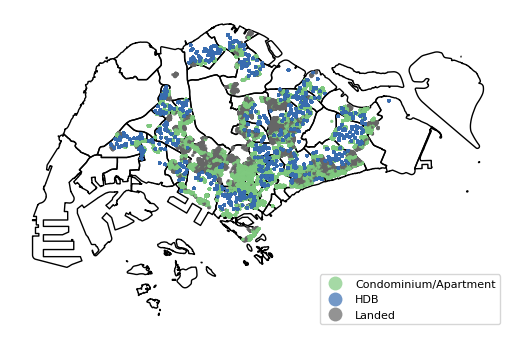

In [125]:
# plot distribution of residential
ax = planningArea_shp.plot(ec='k',fc='None')
combined_residential_df.plot(ax=ax,column='Property Type',markersize=1.5,
                             figsize=(10,6),
                             alpha=0.7,
                                legend=True,
                                legend_kwds={"fontsize":8,"loc":"lower right"},
                                cmap='Accent')

# ax.set_title("Distribution of private properties (sale transaction)")
ax.axis('off')
# plt.savefig(os.path.join(r"Exported_Data\exported_figures",
#                          "property_types_distribution.png"),
#             bbox_inches = "tight")

# Stacked/Local DID
- Define treatment clearly (i.e. properties affected by flood determined by buffer radius)
    - treated properties: properties within buffer radius of flood area (labelled as True) i.e. properties that have experienced at least one flood within observation period.
    - control group: properties outside buffer radius of flood area (labelled as False)
- Define post-treatment clearly
    - post-treatment: post $t$ duration of flood (i.e. within $t$ months of flood)
## Buffer optimisation
- `flood_buffer`: Define a small treatment buffer radius: within the radius are properties that are deemed to have flooded (i.e. `Treat`). Outside the radius are properties that are the control group, deemed to have no flood treatment.
- `within_X_months_post_flood`: Define a bigger "treatment" buffer radius, where all properties within this bigger "treatment" radius represent sale transactions after the flood treatment (i.e. `Post`)
- Note: not all `within_X_months_post_flood` True values will correspond with `flood_buffer` values. Some False values will appear in flood_buffer because sometimes a certain Project can be very big, and only part of the buildings in the same Project will intersect with flood buffer. But that is fine because the treated buildings are clearly defined, buildings in the same Project that does not fall within the flood buffer will just fall under control group.


In [10]:
buffer_dir = r"Exported_Data\flood_buffer_dist"
buffer_fps = {re.match(r".*20260222_buffer(.*?)_network.*",fp).group(1): os.path.join(buffer_dir, fp) for fp in os.listdir(buffer_dir) if re.match(r".*20260222_buffer(.*?)_network.*adaptationProjectName.*",fp)}
print(len(buffer_fps))
buffer_fps

20


{'1000': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer1000_networkDepthNone_adaptationProjectName.csv',
 '100': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer100_networkDepthNone_adaptationProjectName.csv',
 '150': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer150_networkDepthNone_adaptationProjectName.csv',
 '200': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer200_networkDepthNone_adaptationProjectName.csv',
 '250': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer250_networkDepthNone_adaptationProjectName.csv',
 '300': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer300_networkDepthNone_adaptationProjectName.csv',
 '350': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffer350_networkDepthNone_adaptationProjectName.csv',
 '400': 'Exported_Data\\flood_buffer_dist\\floodPrivateResidential_20260222_buffe

## Export df with different TREAT and POST columns from different flood buffer radius

In [ ]:
property_attributes_columns = ['Building_Name', 'Transacted_Price_($)', 'Sale_Date', 'Address',
       'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)', 'Unit_Price_($_PSM)',
       'Property_Type', 'Tenure', 'Completion_Date', 'Postal_Code',
       'Postal_District', 'Postal_Sector', 'REGION_N', 'PLN_AREA_N',
       'ROAD_NAME', 'Project_Name', 'year', 'month', 'Building_Age',
       'Floor_level', 'is_ground_floor', 'SUBZONE_N','Flood_Date'] # only flood date has slightly different data distribution, but it's fine if we are snipping dataframe based on min and max flood date

treat_flood_list = [] # to store TREAT_d* columns
post_flood_list = [] # to store POST_flood_t* columns
for buffer_dist, fp in buffer_fps.items():
    df = pd.read_csv(fp)
    # define Treatment column (properties that are within flood buffer - have experienced at least one flood within obs period)
    treatment_column = df[f"flood_buffer"]
    treatment_column.name = f"TREAT_d{buffer_dist}"
    print(f"TREAT_d{buffer_dist}: {treatment_column.sum()}")
    treat_flood_list.append(treatment_column)
    # define Post column (observations after flood date)
    post_columns = [i for i in df.columns if bool(re.search(r"within_.*_months_post_flood",i))]
    post_columns_df = df[post_columns]
    # rename columns
    rename_columns = {i: i.replace("within","POST").replace("post_flood",f"d{buffer_dist}") for i in post_columns}
    post_columns_df = post_columns_df.rename(columns = rename_columns)
    post_flood_list.append(post_columns_df)
buffer_df = pd.concat([df[property_attributes_columns]]+treat_flood_list+post_flood_list,axis=1)
# buffer_df.reset_index(names=["index"]).to_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer.csv",index=False)

TREAT_d1000: 193611
TREAT_d100: 11043
TREAT_d150: 21228
TREAT_d200: 32193
TREAT_d250: 43524
TREAT_d300: 54308
TREAT_d350: 65830
TREAT_d400: 77603
TREAT_d450: 90279
TREAT_d500: 104769


C:\Users\hypak\AppData\Local\Temp\ipykernel_30392\2895436885.py:11: DtypeWarning: Columns (40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fp)


TREAT_d50: 2510
TREAT_d550: 116666
TREAT_d600: 129299
TREAT_d650: 139563
TREAT_d700: 149403
TREAT_d750: 159257
TREAT_d800: 168551
TREAT_d850: 176434
TREAT_d900: 182973
TREAT_d950: 187617


,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,Tenure,...,POST_3_months_d950,POST_4_months_d950,POST_5_months_d950,POST_6_months_d950,POST_7_months_d950,POST_8_months_d950,POST_9_months_d950,POST_10_months_d950,POST_11_months_d950,POST_12_months_d950
0,481 YIO CHU KANG ROAD,950000,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,Condominium/Apartment,Leasehold,...,False,False,False,False,False,False,False,False,False,False
1,52 HUME AVENUE,1650000,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,Condominium/Apartment,Freehold,...,False,False,False,False,False,False,False,False,False,False
2,41 BRIGHT HILL DRIVE,1051000,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New/Sub Sale,Strata,68.0,15456,Condominium/Apartment,Leasehold,...,False,False,False,False,False,False,False,False,False,False
3,103 HILLVIEW RISE,730000,2014-01-03,103 HILLVIEW RISE #10-11,New/Sub Sale,Strata,48.0,15208,Condominium/Apartment,Leasehold,...,False,False,False,False,False,False,False,False,False,False
4,628 UPPER THOMSON ROAD,2518000,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,Condominium/Apartment,Freehold,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267447,66 POTONG PASIR AVENUE 1,2300000,2025-06-18,66 POTONG PASIR AVENUE 1 #13-30,New/Sub Sale,Strata,102.0,22549,Condominium/Apartment,Leasehold,...,False,False,False,False,True,True,True,True,True,True
267448,19 WOODLANDS AVENUE 6,1600000,2025-06-18,19 WOODLANDS AVENUE 6 #05-26,Resale,Strata,112.0,14286,Condominium/Apartment,Leasehold,...,False,False,False,False,False,False,False,False,False,False
267449,46 MOUNT VERNON ROAD,890000,2025-06-19,46 MOUNT VERNON ROAD #01-47,Resale,Strata,52.0,17115,Condominium/Apartment,Leasehold,...,False,False,False,False,False,False,False,False,False,False
267450,21 BIDADARI PARK DRIVE,1865000,2025-06-20,21 BIDADARI PARK DRIVE #10-26,New/Sub Sale,Strata,69.0,27029,Condominium/Apartment,Leasehold,...,False,False,False,False,True,True,True,True,True,True


## Export local DID df

- Local DID 
    - at least one TRUE value across TREAT groups of different radius, means there must be at least has one flood exposure across different flood buffer of $d$ radius

In [ ]:
buffer_df = pd.read_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer.csv")

buffer_df_localDID = buffer_df[buffer_df[[i for i in buffer_df.columns if bool(re.search(r"TREAT.*",i))]].any(axis=1)]
print(f"Is the biggest control group radius all True? {buffer_df_localDID["TREAT_d1000"].all()}")
print(f"Number of maximum treated properties: {buffer_df_localDID["TREAT_d1000"].sum()}")
print(f"Length of trimmed buffer_df_localDID: {len(buffer_df_localDID)}")
buffer_df_localDID#.to_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer_localDID.csv",index=False)

Is the biggest control group radius all True? True
Number of maximum treated properties: 193611
Length of trimmed buffer_df_localDID: 193611


## Export trimmed time period and local DID df
- Trimmed time period:
    - for each location i.e. Project Name of Building Name, we want to snip pre and post flood
    - i.e. $t$ months before and after flood. 
    - But because one location can experience multiple flood throughout the year, 
    - we just look at t months before oldest (min) flood and t months after the most recent (max) flood
    - this will help to constrain the pre-flood observation period
    - Note: post_flood = False implies that all False values are pre-flood
- Local DID 
    - at least one TRUE value across TREAT groups of different radius, means there must be at least has one flood exposure across different flood buffer of $d$ radius

In [ ]:
def get_pre_flood_df(df_subset,months_before_after_flood=12):
    """for each group by location trim observations to 12 months before oldest (min) flood, and 12 months after most recent (max) flood
    Args:
        df_subset (pd.DataFrame) refers to the specific residential areas within specific subzone/planning area
        months_before_after_flood (int): subset dataframe to consider observations e.g. 12 months pre and post flood. 
        12 months could be reasonable because flood occurs every wet monsoon season
    Returns:
        pd.Series: boolean column that describes whether there is flood within 6 months
    """
    # sort date by oldest date
    df_subset = df_subset.sort_values(by='Sale_Date')
    df_subset['Sale_Date'] = pd.to_datetime(df_subset['Sale_Date'])
    # get maximum flood_date aka latest flood date
    latest_flood_date = pd.to_datetime(df_subset['Flood_Date']).max()
    oldest_flood_date = pd.to_datetime(df_subset['Flood_Date']).min()
    duration_buffer = pd.DateOffset(months=months_before_after_flood)
    mask = (df_subset['Sale_Date'] >= (oldest_flood_date - duration_buffer)) & (df_subset['Sale_Date'] <= (latest_flood_date + duration_buffer))
    return df_subset[mask]

# for each location i.e. Project Name of Building Name, we want to snip pre and post flood
# i.e. t months before and after flood. 
# But because one location can experience multiple flood throughout the year, 
# we just look at t months before oldest (min) flood and t months after the most recent (max) flood
# this will help to constrain the pre-flood observation period
# Note: post_flood = False implies that all False values are pre-flood
buffer_df = pd.read_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer.csv")
# for each group by location trim observations to 12 months before oldest (min) flood, and 12 months after most recent (max) flood
buffer_df_trimmed = buffer_df.groupby([adaptation_groupby_column.replace(' ','_')]).apply(lambda x: get_pre_flood_df(x, months_before_after_flood=12)).reset_index(drop=True)
print(f"Is the biggest control group radius all True? {buffer_df_trimmed["TREAT_d1000"].all()}")
print(f"Number of maximum treated properties: {buffer_df_trimmed["TREAT_d1000"].sum()}")
print(f"Length of trimmed buffer_df: {len(buffer_df_trimmed)}")
# buffer_df_trimmed.to_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer_trimmed12months.csv",index=False)
buffer_df_trimmed
# local DID (i.e. at least one TRUE value in TREAT group, means there must be at least has one flood exposure across different flood buffer of d radius)
# buffer_df_trimmed[buffer_df_trimmed[[i for i in buffer_df_trimmed.columns if bool(re.search(r"TREAT.*",i))]].any(axis=1)].to_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer_trimmed12months_localDID.csv",index=False)



C:\Users\hypak\AppData\Local\Temp\ipykernel_30392\30647744.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  buffer_df_trimmed = buffer_df.groupby([adaptation_groupby_column.replace(' ','_')]).apply(lambda x: get_pre_flood_df(x, months_before_after_flood=12)).reset_index(drop=True)


Is the biggest control group radius all True? False
Number of maximum treated properties: 81382
Length of trimmed buffer_df: 81766


,index,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,...,POST_3_months_d950,POST_4_months_d950,POST_5_months_d950,POST_6_months_d950,POST_7_months_d950,POST_8_months_d950,POST_9_months_d950,POST_10_months_d950,POST_11_months_d950,POST_12_months_d950
0,117490,1 LORONG 24 GEYLANG,618000,2017-11-30,1 LORONG 24 GEYLANG #06-21,Resale,Strata,52.0,11885,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
1,117501,1 LORONG 24 GEYLANG,645888,2017-12-01,1 LORONG 24 GEYLANG #06-04,Resale,Strata,54.0,11961,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
2,119104,1 LORONG 24 GEYLANG,668000,2018-07-10,1 LORONG 24 GEYLANG #08-18,Resale,Strata,51.0,13098,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
3,120081,1 LORONG 24 GEYLANG,660000,2019-01-18,1 LORONG 24 GEYLANG #04-18,Resale,Strata,53.0,12453,Condominium/Apartment,...,True,True,True,True,True,True,True,True,True,True
4,120728,1 LORONG 24 GEYLANG,668000,2019-06-27,1 LORONG 24 GEYLANG #06-09,Resale,Strata,54.0,12370,Condominium/Apartment,...,False,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81761,70100,81E JALAN SENANG,3600000,2022-09-09,81E JALAN SENANG,Resale,Land,175.7,20489,Landed,...,False,False,False,False,True,True,True,True,True,True
81762,73525,105 JALAN CHEMPAKA KUNING,4350000,2023-07-12,105 JALAN CHEMPAKA KUNING,Resale,Land,313.1,13893,Landed,...,False,False,False,False,False,True,True,True,True,True
81763,134734,2 AKYAB ROAD,1660000,2015-09-04,2 AKYAB ROAD #20-01,Resale,Strata,121.0,13719,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
81764,237747,48 SEA BREEZE ROAD,2980000,2017-11-13,48 SEA BREEZE ROAD,Resale,Land,269.6,11053,Landed,...,False,False,False,False,False,False,False,False,False,False


In [11]:
buffer_df_trimmed = pd.read_csv(r"Exported_Data\flood_buffer_dist\processed_df\master_treat_post_buffer_trimmed12months.csv")
buffer_df_trimmed

,index,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,...,POST_3_months_d950,POST_4_months_d950,POST_5_months_d950,POST_6_months_d950,POST_7_months_d950,POST_8_months_d950,POST_9_months_d950,POST_10_months_d950,POST_11_months_d950,POST_12_months_d950
0,117490,1 LORONG 24 GEYLANG,618000,2017-11-30,1 LORONG 24 GEYLANG #06-21,Resale,Strata,52.0,11885,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
1,117501,1 LORONG 24 GEYLANG,645888,2017-12-01,1 LORONG 24 GEYLANG #06-04,Resale,Strata,54.0,11961,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
2,119104,1 LORONG 24 GEYLANG,668000,2018-07-10,1 LORONG 24 GEYLANG #08-18,Resale,Strata,51.0,13098,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
3,120081,1 LORONG 24 GEYLANG,660000,2019-01-18,1 LORONG 24 GEYLANG #04-18,Resale,Strata,53.0,12453,Condominium/Apartment,...,True,True,True,True,True,True,True,True,True,True
4,120728,1 LORONG 24 GEYLANG,668000,2019-06-27,1 LORONG 24 GEYLANG #06-09,Resale,Strata,54.0,12370,Condominium/Apartment,...,False,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81761,70100,81E JALAN SENANG,3600000,2022-09-09,81E JALAN SENANG,Resale,Land,175.7,20489,Landed,...,False,False,False,False,True,True,True,True,True,True
81762,73525,105 JALAN CHEMPAKA KUNING,4350000,2023-07-12,105 JALAN CHEMPAKA KUNING,Resale,Land,313.1,13893,Landed,...,False,False,False,False,False,True,True,True,True,True
81763,134734,2 AKYAB ROAD,1660000,2015-09-04,2 AKYAB ROAD #20-01,Resale,Strata,121.0,13719,Condominium/Apartment,...,False,False,False,False,False,False,False,False,False,False
81764,237747,48 SEA BREEZE ROAD,2980000,2017-11-13,48 SEA BREEZE ROAD,Resale,Land,269.6,11053,Landed,...,False,False,False,False,False,False,False,False,False,False


In [19]:
attr_columns = [i for i in buffer_df_trimmed.columns if not bool(re.search(r"POST.*|TREAT.*",i))]
attr_columns

['index',
 'Building_Name',
 'Transacted_Price_($)',
 'Sale_Date',
 'Address',
 'Type_of_Sale',
 'Type_of_Area',
 'Area_(SQM)',
 'Unit_Price_($_PSM)',
 'Property_Type',
 'Tenure',
 'Completion_Date',
 'Postal_Code',
 'Postal_District',
 'Postal_Sector',
 'REGION_N',
 'PLN_AREA_N',
 'ROAD_NAME',
 'Project_Name',
 'year',
 'month',
 'Building_Age',
 'Floor_level',
 'is_ground_floor',
 'SUBZONE_N',
 'Flood_Date']

In [ ]:
# for the larger buffer radius, filtering values == True - this serves as the filter to identify all the control group properties
# for the inner buffer radius, values that are True serve as the treatment group that are within the smaller radius, if they are True within the smaller radius, they must be True for the larger radius
# for the post treatment (POST* columns), filter the ones that correspond to the larger 
buffer_df_trimmed[["year","month","Flood_Date","TREAT_d100","TREAT_d500"]][buffer_df_trimmed["TREAT_d500"]==True]

,year,month,Flood_Date,TREAT_d100,TREAT_d500
0,2017,11,NaN,False,True
1,2017,12,NaN,False,True
2,2018,7,NaN,False,True
3,2019,1,2018-11-11,False,True
4,2019,6,2018-11-11,False,True
...,...,...,...,...,...
81691,2015,8,2014-11-13,False,True
81762,2023,7,2022-11-12,False,True
81763,2015,9,2014-07-29,True,True
81764,2017,11,2013-10-15,False,True


In [35]:
[i for i in buffer_df_trimmed.columns if bool(re.search(r"POST.*",i))]

['POST_1_months_d1000',
 'POST_2_months_d1000',
 'POST_3_months_d1000',
 'POST_4_months_d1000',
 'POST_5_months_d1000',
 'POST_6_months_d1000',
 'POST_7_months_d1000',
 'POST_8_months_d1000',
 'POST_9_months_d1000',
 'POST_10_months_d1000',
 'POST_11_months_d1000',
 'POST_12_months_d1000',
 'POST_1_months_d100',
 'POST_2_months_d100',
 'POST_3_months_d100',
 'POST_4_months_d100',
 'POST_5_months_d100',
 'POST_6_months_d100',
 'POST_7_months_d100',
 'POST_8_months_d100',
 'POST_9_months_d100',
 'POST_10_months_d100',
 'POST_11_months_d100',
 'POST_12_months_d100',
 'POST_1_months_d150',
 'POST_2_months_d150',
 'POST_3_months_d150',
 'POST_4_months_d150',
 'POST_5_months_d150',
 'POST_6_months_d150',
 'POST_7_months_d150',
 'POST_8_months_d150',
 'POST_9_months_d150',
 'POST_10_months_d150',
 'POST_11_months_d150',
 'POST_12_months_d150',
 'POST_1_months_d200',
 'POST_2_months_d200',
 'POST_3_months_d200',
 'POST_4_months_d200',
 'POST_5_months_d200',
 'POST_6_months_d200',
 'POST_7_mont

In [36]:
buffer_df_trimmed[["year","month","Flood_Date","TREAT_d100","TREAT_d500",'POST_1_months_d1000']][buffer_df_trimmed["TREAT_d500"]==True]

,year,month,Flood_Date,TREAT_d100,TREAT_d500,POST_1_months_d1000
0,2017,11,NaN,False,True,False
1,2017,12,NaN,False,True,False
2,2018,7,NaN,False,True,False
3,2019,1,2018-11-11,False,True,False
4,2019,6,2018-11-11,False,True,False
...,...,...,...,...,...,...
81691,2015,8,2014-11-13,False,True,False
81762,2023,7,2022-11-12,False,True,False
81763,2015,9,2014-07-29,True,True,False
81764,2017,11,2013-10-15,False,True,False
